In [21]:
import sys
from pathlib import Path

import polars as pl
import torch
from torchvision.transforms import v2 as transforms

this_path = Path(__file__) if '__file__' in globals() else Path("<undefined>.ipynb").resolve()
work_path = next((p for p in this_path.parents if p.name == "research"), None)
tools_path = work_path / Path("../torch-tools")
sys.path.append(str(tools_path))

ee_tools_path_p = work_path / Path("ee")
sys.path.append(str(ee_tools_path_p))

import utils
from datasets import fetch_handler
from ee_tools.ee_refiner import EERefiner
from ee_tools.ee_trainer import EETrainer
from network import Network, Networks
from exp_manager import ExpManager
from torchvision import models
from trainer import MultiTrainer, Trainer
from hook import HookManager

In [22]:
exp_path = this_path.parent / "exp_model"
pq_path = exp_path / "_results.parquet"
runs_path = exp_path / "runs"

df = pl.read_parquet(pq_path)
df = df.with_columns((pl.lit(str(runs_path) + "/") + pl.col("run_id") + "/state_dict.pt").alias("sd_path"))
runs = df.to_dicts()

# exp.fetch_file_paths("state_dict.pt")

In [23]:
run = runs[2]
print(run.keys())


dict_keys(['run_id', 'model_arc', 'train_dataset', 'val_dataset', 'num_classes', 'train_trans', 'val_trans', 'train_ndata', 'val_ndata', 'epochs', 'max_lr', 'wd', 'batch_size', 'base_epochs', 'iters/epoch', 'iters', 'processed_ndata', 'ndata_per_class', 'div', 'ensembles', 'scale_ch', 'num_params', 'criterion', 'optimizer', 'scheduler', 'step', 'epoch', 'lr', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'dur_total_core', 'dur_total_core_fmt', 'dur_train_core', 'dur_train_core_fmt', 'dur_total', 'dur_total_fmt', 'dur_train', 'dur_train_fmt', 'progress', 'sd_path'])


In [24]:
sd = torch.load(run["sd_path"])

net = getattr(models, run["model_arc"])
num_classes = run["num_classes"]
div = run["div"]

network = Network(EERefiner(net(num_classes=num_classes)).cifar_style().multi_narrow(div=div, agg="mean").init_weights().build())
network.load_state_dict_flexible(sd)

ds_root = work_path / "assets/datasets/"
base_train_ds = fetch_handler(ds_root, "cifar100_train")
base_val_ds = fetch_handler(ds_root, "cifar100_val")
val_trans = [transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True), base_train_ds.normalizer()]
val_ds = base_val_ds.transform(val_trans)
val_dl = val_ds.loader(batch_size=128)


Total Average Activation Rate (across all layers): 0.3851


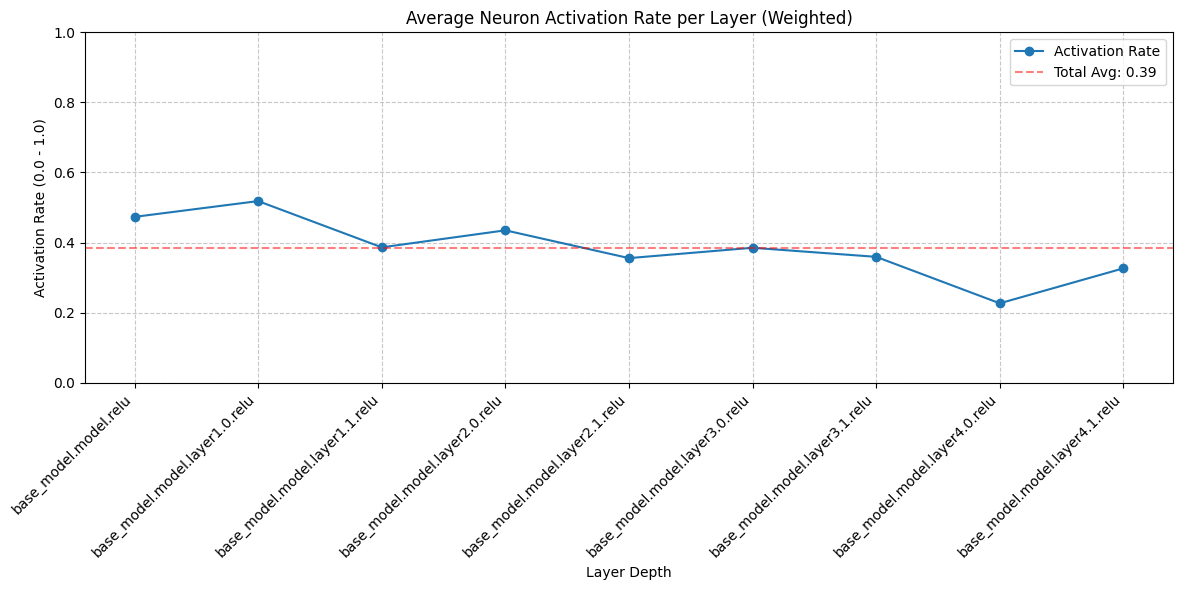

In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. プロセッサ定義: (発火率, バッチサイズ) のタプルを返す
def fire_rate_processor(tensor):
    batch_size = tensor.shape[0]
    # バッチ内の平均発火率
    rate = (tensor.detach().cpu() > 0).float().mean().item()
    return (rate, batch_size)

# 2. 全バッチ計測実行
target_layer_pattern = r".*relu.*" 
layer_fire_rates = {}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = network.to(device)
network.eval()

with HookManager(network) as hm:
    hm.register(target_layer_pattern, processor=fire_rate_processor)
    
    with torch.no_grad():
        for inputs, _ in val_dl:
            inputs = inputs.to(device)
            _ = network(inputs)

    # --- 修正部分: 加重平均による集計 ---
    # hm.storage[layer_name] は [(rate, size), (rate, size), ...] のリスト
    for layer_name, data_list in hm.storage.items():
        total_weighted_sum = 0
        total_samples = 0
        
        for rate, size in data_list:
            total_weighted_sum += rate * size
            total_samples += size
        
        # ゼロ除算回避（念のため）
        if total_samples > 0:
            layer_fire_rates[layer_name] = total_weighted_sum / total_samples
        else:
            layer_fire_rates[layer_name] = 0.0
    # -----------------------------------

# 全体の平均発火率（全層のマクロ平均）
total_avg_rate = np.mean(list(layer_fire_rates.values()))
print(f"Total Average Activation Rate (across all layers): {total_avg_rate:.4f}")

# 3. 可視化
plt.figure(figsize=(12, 6))
layers = list(layer_fire_rates.keys())
rates = list(layer_fire_rates.values())

plt.plot(rates, marker='o', linestyle='-', label='Activation Rate')
plt.axhline(y=total_avg_rate, color='r', linestyle='--', alpha=0.5, label=f'Total Avg: {total_avg_rate:.2f}')

plt.title("Average Neuron Activation Rate per Layer (Weighted)")
plt.xlabel("Layer Depth")
plt.ylabel("Activation Rate (0.0 - 1.0)")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

if len(layers) > 0:
    step = max(1, len(layers) // 20)
    indices = range(0, len(layers), step)
    plt.xticks(indices, [layers[i] for i in indices], rotation=45, ha='right')

plt.tight_layout()
plt.show()